# Training a Seismic Facies Segmentation Model with PyTorch

Minerva offers a wide range of data modules and models to train a variety of machine learning models for several applications, such as:
- Human Activity Recognition using Inertial Sensors
- Time Series Classification
- Image Segmentation

Let's see how to train a seismic facies segmentation model using PyTorch and Minerva.

## Seismic Facies Segmentation

Seismic facies segmentation is a crucial task in the oil and gas industry. It involves the classification of seismic data into different facies classes. The goal is to identify the different geological formations present in the subsurface. This information is essential for the exploration and production of oil and gas.

In this notebook, we will train a seismic facies segmentation model using a SET-R architecture. The model will be trained on the [F3 Seismic Dataset](https://terranubis.com/datainfo/Netherlands-F3-Block-Complete) from the Netherlands. The dataset contains seismic data and corresponding facies labels.

The dataset consists in two directories, one named `images` and another named `annotations`. Both directories contains three subdirectories, one for each split: `train`, `val` and `test`. The `images` directory contains the seismic data in TIFF format, while the `annotations` directory contains the facies labels in PNG format. The name of the images and annotations are the same, so we can easily match them.

Below is an example of the seismic data and facies labels from the F3 dataset:

```
root_dir:
├── images
│   ├── train
│   │   ├── il_01.tif
│   │   ├── il_02.tif
│   │   └── ...
│   ├── val
│   │   ├── il_01.tif
│   │   ├── il_02.tif
│   │   └── ...
│   └── test
│       ├── il_01.tif
│       ├── il_02.tif
│       └── ...
├── annotations
│   ├── train
│   │   ├── il_01.png
│   │   ├── il_02.png
│   │   └── ...
│   ├── val
│   │   ├── il_01.png
│   │   ├── il_02.png
│   │   └── ...
│   └── test
│       ├── il_01.png
│       ├── il_02.png
│       └── ...

```

Let's instatiate the dataset, change the `root_path` variable in the code to point to the correct path in your environment.

In [1]:
from pathlib import Path
from minerva.data.readers import PNGReader, TiffReader

root_path = Path("/workspaces/seismic/data/f3_segmentation")
image_path = TiffReader(root_path / "images")
mask_path = PNGReader(root_path / "annotations")
print(f"There are {len(image_path)} images and {len(mask_path)} masks!")

There are 1502 images and 1502 masks!


In [3]:
# Let's take a look at the first image and mask
image, label = image_path[0], mask_path[0]

# As image is a 3-channel image, let's pick only the first channel
image = image[:, :, 0]

print(f"Image shape: {image.shape}, Label shape: {label.shape}")

Image shape: (255, 701), Label shape: (255, 701)


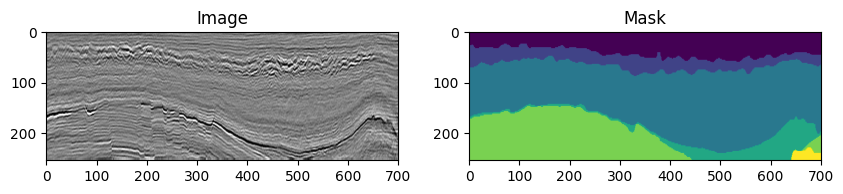

In [9]:
# And plot using matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Image")
plt.subplot(1, 2, 2)
plt.imshow(label, )
plt.title("Mask")
plt.show()